# Exercise 1: Association Analysis
### Frequent Itemset Mining using Apriori algorithm
In this exercise, you will explore the Apriori Algorithm which is a machine learning algorithm used to gain insight into the structured relationships between different items involved. The most prominent practical application of the algorithm is to recommend products based on those that are already present in the user’s cart. 
To be able to use the Apriori algorithm you will need to install the mlxtend library in Anaconda.  
First, launch Anaconda and add a channel namely conda-forge by clicking on Channels button and then Add button.
Then, Open a command prompt and execute the following command:
conda install mlxtend –channel Conda-forge
OR 
conda install -c conda-forge mlxtend

#### Learning Outcomes
1. be familiar with the Apriori Algorithm and the association rules libraries
2. visualise the data and get insight from your visualisation

In [45]:
%matplotlib inline

In [46]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules #machine learning extension library
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('https://gist.githubusercontent.com/Harsh-Git-Hub/2979ec48043928ad9033d8469928e751/raw/72de943e040b8bd0d087624b154d41b2ba9d9b60/retail_dataset.csv', sep=',')
#df = pd.read_csv('datasets/retail_dataset.csv') 
print(df.shape)
df.head(10)


(315, 7)


,0,1,2,3,4,5,6
0,Bread,Wine,Eggs,Meat,Cheese,Pencil,Diaper
1,Bread,Cheese,Meat,Diaper,Wine,Milk,Pencil
2,Cheese,Meat,Eggs,Milk,Wine,NaN,NaN
3,Cheese,Meat,Eggs,Milk,Wine,NaN,NaN
4,Meat,Pencil,Wine,NaN,NaN,NaN,NaN
5,Eggs,Bread,Wine,Pencil,Milk,Diaper,Bagel
6,Wine,Pencil,Eggs,Cheese,NaN,NaN,NaN
7,Bagel,Bread,Milk,Pencil,Diaper,NaN,NaN
8,Bread,Diaper,Cheese,Milk,Wine,Eggs,NaN
9,Bagel,Wine,Diaper,Meat,Pencil,Eggs,Cheese


Each row of the dataset represents items that were purchased together on the same day at the same store. The dataset is a sparse dataset as relatively high percentage of data is NA or NaN or equivalent.

In [49]:
# Exploring the columns of the data
items = set()
for col in df:
    items.update(df[col].dropna().unique())    
print(items)


{'Milk', 'Meat', 'Wine', 'Bagel', 'Bread', 'Cheese', 'Pencil', 'Diaper', 'Eggs'}


### Data Preprocessing
To make use of the Apriori module given by mlxtend library, we need to convert the dataset according to its liking. The Apriori module requires a dataframe that has either 0 and 1 or True and False as data. The data we have is all strings (name of items), we need to One Hot Encode the data.

In [50]:
itemset = set(items)
encoded_vals = []
for index, row in df.iterrows():
    rowset = set(row) 
    labels = {}
    uncommons = list(itemset - rowset)
    commons = list(itemset.intersection(rowset))
    for uc in uncommons:
        labels[uc] = 0
    for com in commons:
        labels[com] = 1
    #print(labels)
    encoded_vals.append(labels)
print(type(encoded_vals))
encoded_vals[0]
ohe_df = pd.DataFrame(encoded_vals)

<class 'list'>


In [53]:
#ohe_df.head()
df_ohe_bool = ohe_df.astype(bool)
df_ohe_bool.head()

,Bagel,Milk,Wine,Meat,Bread,Cheese,Pencil,Diaper,Eggs
0,False,False,True,True,True,True,True,True,True
1,False,True,True,True,True,True,True,True,False
2,False,True,True,True,False,True,False,False,True
3,False,True,True,True,False,True,False,False,True
4,False,False,True,True,False,False,True,False,False


In [56]:
freq_items = apriori(df_ohe_bool, min_support=0.2, use_colnames=True, verbose=1)
freq_items.head(8)

Processing 4 combinations | Sampling itemset size 4


,support,itemsets
0,0.425397,(Bagel)
1,0.501587,(Milk)
2,0.438095,(Wine)
3,0.476190,(Meat)
4,0.504762,(Bread)
5,0.501587,(Cheese)
6,0.361905,(Pencil)
7,0.406349,(Diaper)


In [63]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)
rules.sort_values(['confidence', 'lift'], ascending =[False, False])
print(len(rules))
rules.head()

14


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Bagel),(Bread),0.425397,0.504762,0.279365,0.656716,1.301042,0.064641,1.442650
1,(Cheese),(Milk),0.501587,0.501587,0.304762,0.607595,1.211344,0.053172,1.270148
2,(Milk),(Cheese),0.501587,0.501587,0.304762,0.607595,1.211344,0.053172,1.270148
3,(Wine),(Cheese),0.438095,0.501587,0.269841,0.615942,1.227986,0.050098,1.297754
4,(Cheese),(Meat),0.501587,0.476190,0.323810,0.645570,1.355696,0.084958,1.477891


The result of the association analysis shows which item is frequently purchased with other items only for those with confidence values greater than 0.6.

### Visualising the Results

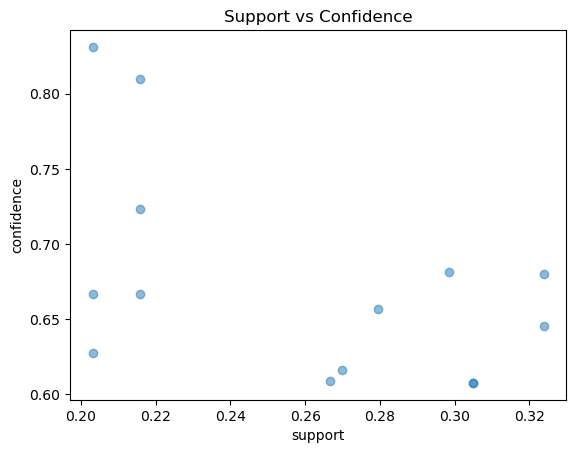

In [64]:
plt.scatter(rules['support'], rules['confidence'], alpha=0.5)
plt.xlabel('support')
plt.ylabel('confidence')
plt.title('Support vs Confidence')
plt.show()

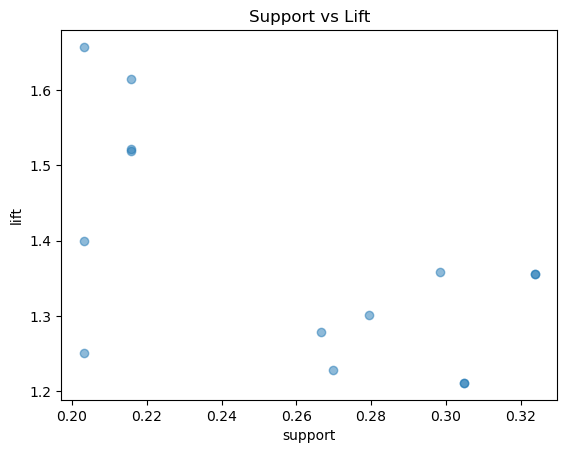

In [65]:
plt.scatter(rules['support'], rules['lift'], alpha=0.5)
plt.xlabel('support')
plt.ylabel('lift')
plt.title('Support vs Lift')
plt.show()

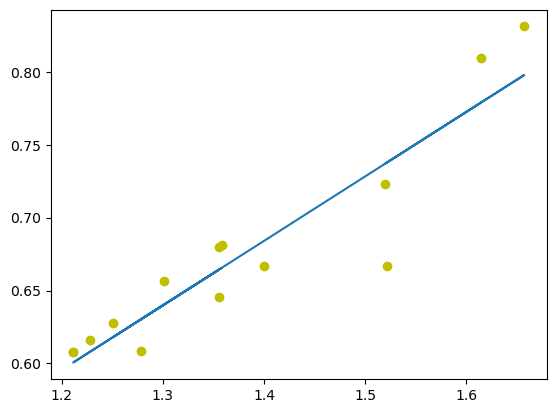

In [66]:
fit = np.polyfit(rules['lift'], rules['confidence'], 1)
fit_fn = np.poly1d(fit)
plt.plot(rules['lift'], rules['confidence'], 'yo', rules['lift'], 
 fit_fn(rules['lift']))